In [84]:
import torch
from torch import nn
import ptwt
import numpy as np
from torch_geometric.nn.conv import GATConv
from torch_geometric.nn.norm import GraphNorm
from torch_geometric.nn import Sequential
from dataset import EEGDataset
from torch_geometric.loader import DataLoader
import torch.utils.data as torchdata
import tqdm
from math import floor
import gc
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


In [3]:
train_frac = 0.02
val_frac = 0.001

dataset = EEGDataset(root="/home/hice1/mchen439/data/TUH-Processed", frac=train_frac + val_frac)
num_train = int(len(dataset) * (train_frac / (train_frac + val_frac)))
num_val = len(dataset) - num_train
train_dataset, val_dataset = torchdata.random_split(dataset, [num_train, num_val])
print("Train and Validation Dataset Length: ", len(train_dataset), len(val_dataset))

Loading 1 subjects


100%|██████████| 1/1 [00:00<00:00, 20.44it/s]


Train and Validation Dataset Length:  18 2


In [4]:
train_loader = DataLoader(train_dataset, batch_size=64, num_workers=0, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, num_workers=0, shuffle=False)
print(len(train_loader), len(val_loader))

1 1


In [5]:
BANDS = ['delta', 'theta', 'alpha', 'beta', 'gamma']

In [84]:
class WaveletEncoderDecoder(nn.Module):
	def __init__(self, bands, decoded_features, encoded_features, enc_width, enc_downsample):
		super(WaveletEncoderDecoder, self).__init__()

		self.encoders = nn.ParameterDict()
		self.decoded_features = decoded_features
		self.encoded_features = encoded_features

		enc_width = [e if e % 2 else e+1 for e in enc_width]

		band_input = {
			'delta': 241,
			'theta': 241,
			'alpha': 481,
			'beta': 961,
			'gamma': 1921
		}

		band_output = {
			'delta': 246,
			'theta': 246,
			'alpha': 486,
			'beta': 966,
			'gamma': 1926
		}

		for band in bands:
			self.encoders[band] = nn.Sequential()
			decoded_features = self.decoded_features
			for i, (width, downsample) in enumerate(zip(enc_width, enc_downsample)):
				self.encoders[band].add_module("Encoder_{}".format(i), nn.Sequential(
					nn.Conv1d(decoded_features, encoded_features, width, stride=downsample, padding=width // 2),
					nn.Dropout1d(0.1),
					nn.GroupNorm(encoded_features // 2, encoded_features),
					nn.GELU(),
				))
				decoded_features = encoded_features

		self.decoders = nn.ParameterDict()
		decoded_features = self.decoded_features
		for band in bands:
			self.decoders[band] = nn.Sequential()
			encoded_features = self.encoded_features	
			for i, (width, upsample) in enumerate(zip(enc_width[::-1], enc_downsample[::-1])):
				self.decoders[band].add_module("Decoder_{}".format(i), nn.Sequential(
					nn.ConvTranspose1d(encoded_features, decoded_features, width, stride=upsample, padding=width // 2),
					nn.Dropout(0.1),
					nn.GroupNorm(1, decoded_features),
					nn.GELU(),
				))
				encoded_features = decoded_features
			
			self.decoders[band].add_module("Decoder_Final", nn.Linear(band_input[band], band_output[band]))


	def forward(self, data):
		assert isinstance(data, dict)
		encodings = dict()

		for band in BANDS:
			encodings[band] = self.encoders[band](data[band])

		decodings = dict()

		for band in BANDS:
			decodings[band] = self.decoders[band](encodings[band])

		return encodings, decodings


In [249]:
class GNNWaveletEncoderDecoder(nn.Module):
	def __init__(self, bands, num_channels, enc_width, enc_downsample, heads):
		super(GNNWaveletEncoderDecoder, self).__init__()

		self.conv_encoders = nn.ParameterDict()
		self.decoders = nn.ParameterDict()

		self.enc_width = [e if e % 2 else e+1 for e in enc_width]
		self.enc_downsample = enc_downsample

		self.num_channels = num_channels

		self.gnn_encoders = nn.ParameterDict()
		self.encoded_features = []
		self.heads = heads

		self.band_input = {
			'delta': 11,
			'theta': 11,
			'alpha': 21,
			'beta': 41,
			'gamma': 81
		}

		self.band_linear = {
			'delta': 220,
			'theta': 220,
			'alpha': 460,
			'beta': 940,
			'gamma': 1900
		}

		self.band_output = {
			'delta': 246,
			'theta': 246,
			'alpha': 486,
			'beta': 966,
			'gamma': 1926
		}

		for band in bands:
			self.conv_encoders[band] = nn.Sequential()
			for i, (width, downsample) in enumerate(zip(self.enc_width, self.enc_downsample)):
				self.conv_encoders[band].add_module("Encoder_{}".format(i), nn.Sequential(
					nn.Conv1d(self.num_channels, self.num_channels, width, stride=downsample, padding=width // 2),
					nn.Dropout1d(0.1),
					nn.GroupNorm(1, self.num_channels), # Equivalent to LayerNorm
					nn.GELU(),
				))

			self.gnn_encoders[band] = Sequential('x, edge_index, edge_attr', [
				(GATConv(self.band_input[band], self.band_input[band], heads=self.heads, concat=False, dropout=0.1), 'x, edge_index, edge_attr -> x'),
				(GATConv(self.band_input[band], self.band_input[band], heads=self.heads, concat=False, dropout=0.1), 'x, edge_index, edge_attr -> x'),
			])


		for band in bands:
			self.decoders[band] = nn.Sequential()
			for i, (width, upsample) in enumerate(zip(enc_width[::-1], enc_downsample[::-1])):
				self.decoders[band].add_module("Decoder_{}".format(i), nn.Sequential(
					nn.ConvTranspose1d(num_channels, num_channels, width, stride=upsample, padding=width // 2),
					nn.Dropout(0.1),
					nn.GroupNorm(1, self.num_channels),
					nn.GELU(),
				))
			
			self.decoders[band].add_module("Decoder_Final", nn.Linear(self.band_linear[band], self.band_output[band]))


	def forward(self, x, data):
		assert isinstance(data, dict)
		encodings = dict()

		for band in BANDS:
			encodings[band] = self.conv_encoders[band](data[band])
			encodings[band] = self.gnn_encoders[band](encodings[band].view(-1, encodings[band].shape[-1]), x.edge_index, x.edge_attr)

		decodings = dict()

		for band in BANDS:
			raw_data = encodings[band].view(-1, self.num_channels, encodings[band].shape[-1])
			decodings[band] = self.decoders[band](raw_data)

		return encodings, decodings


In [250]:
enc_width = (3, 2, 2, 2)
enc_downsample = (3, 2, 2, 2)

gnn_wavelet = GNNWaveletEncoderDecoder(bands=BANDS, num_channels=19, enc_downsample=enc_downsample, heads=2, enc_width=enc_width).to(device)
#conv_wavelet = WaveletEncoderDecoder(bands=BANDS, decoded_features=19, encoded_features=256, enc_width=enc_width, enc_downsample=enc_downsample).to(device)
optimizer = torch.optim.Adam(gnn_wavelet.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()
print("Total parameters:", sum(p.numel() for p in gnn_wavelet.parameters() if p.requires_grad))

Total parameters: 4980645


In [251]:
#print(conv_wavelet)
print(gnn_wavelet)

GNNWaveletEncoderDecoder(
  (conv_encoders): ParameterDict(
      (delta): Object of type: Sequential
      (theta): Object of type: Sequential
      (alpha): Object of type: Sequential
      (beta): Object of type: Sequential
      (gamma): Object of type: Sequential
    (delta): Sequential(
      (Encoder_0): Sequential(
        (0): Conv1d(19, 19, kernel_size=(3,), stride=(3,), padding=(1,))
        (1): Dropout1d(p=0.1, inplace=False)
        (2): GroupNorm(1, 19, eps=1e-05, affine=True)
        (3): GELU(approximate='none')
      )
      (Encoder_1): Sequential(
        (0): Conv1d(19, 19, kernel_size=(3,), stride=(2,), padding=(1,))
        (1): Dropout1d(p=0.1, inplace=False)
        (2): GroupNorm(1, 19, eps=1e-05, affine=True)
        (3): GELU(approximate='none')
      )
      (Encoder_2): Sequential(
        (0): Conv1d(19, 19, kernel_size=(3,), stride=(2,), padding=(1,))
        (1): Dropout1d(p=0.1, inplace=False)
        (2): GroupNorm(1, 19, eps=1e-05, affine=True)
     

In [252]:
def _std_norm(x):
	mean = torch.mean(x, dim=(0, 1, 2), keepdim=True)
	std = torch.std(x, dim=(0, 1, 2), keepdim=True)
	x = (x - mean) / std
	return x

In [253]:
def train_one_epoch(model, optimizer, loss_fn, train_loader):
	loss_sum = 0
	model.train()

	pbar = tqdm.trange(len(train_loader), desc="Training")
	data_iterator = iter(train_loader)
	for iteration in pbar:
		data = next(data_iterator)
		dbt_dwpt = ptwt.WaveletPacket(torch.tensor(np.array(data.x)).float().to(device),
									wavelet='db4',
									mode='reflect',
									maxlevel=6,
									axis=-1)
		relevant_bands = [dbt_dwpt['aaaaaa'], dbt_dwpt['aaaaad'], dbt_dwpt['aaaad'],
		 dbt_dwpt['aaad'], dbt_dwpt['aad']]

		inputs = dict(zip(BANDS, relevant_bands))

		optimizer.zero_grad()

		encodings, decodings = model(data, inputs)

		delta_loss = loss_fn(inputs['delta'], decodings['delta'])
		theta_loss = loss_fn(inputs['theta'], decodings['theta'])
		alpha_loss = loss_fn(inputs['alpha'], decodings['alpha'])
		beta_loss =  loss_fn(inputs['beta'], decodings['beta'])
		gamma_loss = loss_fn(inputs['gamma'], decodings['gamma'])

		loss = delta_loss + theta_loss + alpha_loss + beta_loss + gamma_loss
		loss.backward()
		optimizer.step()
		loss_sum += loss.item()

		pbar.set_postfix(loss=loss.item(),
			delta_loss=delta_loss.item(),
			theta_loss=theta_loss.item(),
			alpha_loss=alpha_loss.item(),
			beta_loss=beta_loss.item(),
			gamma_loss=gamma_loss.item())
	
	return loss_sum

In [254]:
def validate_one_epoch(model, loss_fn, val_loader):
	loss_sum = 0
	model.eval()

	pbar = tqdm.trange(len(val_loader), desc="Validating")
	data_iterator = iter(val_loader)
	for iteration in pbar:
		data = next(data_iterator).x
		data = torch.tensor(np.array(data)).float().to(device)
		dbt_dwpt = ptwt.WaveletPacket(data,
									wavelet='db4',
									mode='reflect',
									maxlevel=6,
									axis=-1)
		relevant_bands = [dbt_dwpt['aaaaaa'], dbt_dwpt['aaaaad'], dbt_dwpt['aaaad'],
		 dbt_dwpt['aaad'], dbt_dwpt['aad']]

		inputs = dict(zip(BANDS, relevant_bands))

		encodings, decodings = model(inputs)

		delta_loss = loss_fn(inputs['delta'], decodings['delta'])
		theta_loss = loss_fn(inputs['theta'], decodings['theta'])
		alpha_loss = loss_fn(inputs['alpha'], decodings['alpha'])
		beta_loss =  loss_fn(inputs['beta'], decodings['beta'])
		gamma_loss = loss_fn(inputs['gamma'], decodings['gamma'])

		loss = delta_loss + theta_loss + alpha_loss + beta_loss + gamma_loss
		loss_sum += loss.item()

		pbar.set_postfix(loss=loss.item(),
			delta_loss=delta_loss.item(),
			theta_loss=theta_loss.item(),
			alpha_loss=alpha_loss.item(),
			beta_loss=beta_loss.item(),
			gamma_loss=gamma_loss.item())

	return loss_sum

In [255]:
for epoch_idx in range(5):
	training_loss = train_one_epoch(gnn_wavelet, optimizer, loss_fn, train_loader)
	#val_loss = validate_one_epoch(conv_wavelet, loss_fn, val_loader)
	#print("Epoch: ", epoch_idx, "Total Training Loss: ", training_loss, "Total Validation Loss: ", val_loss)
	print("Epoch: ", epoch_idx, "Total Training Loss: ", training_loss)

Training: 100%|██████████| 1/1 [05:07<00:00, 307.95s/it, alpha_loss=0.149, beta_loss=0.154, delta_loss=0.184, gamma_loss=0.145, loss=0.766, theta_loss=0.134]


Epoch:  0 Total Training Loss:  0.7658244371414185


Training:   0%|          | 0/1 [01:26<?, ?it/s]


KeyboardInterrupt: 

In [91]:
torch.save(conv_wavelet.state_dict, "/home/hice1/mchen439/scratch/models/ConvWavelet.pt")

In [97]:
conv_wavelet.eval()

for item in val_loader:
    data = item.x
    data = torch.tensor(np.array(data)).float().to(device)
    dbt_dwpt = ptwt.WaveletPacket(data,
                                wavelet='db4',
                                mode='reflect',
                                maxlevel=6,
                                axis=-1)
    relevant_bands = [dbt_dwpt['aaaaaa'], dbt_dwpt['aaaaad'], dbt_dwpt['aaaad'],
        dbt_dwpt['aaad'], dbt_dwpt['aad']]

    inputs = dict(zip(BANDS, relevant_bands))

    encodings, decodings = conv_wavelet(inputs)

    print(inputs['delta'].shape, encodings['delta'].shape, decodings['delta'].shape)


    


torch.Size([727, 19, 246]) torch.Size([727, 256, 11]) torch.Size([727, 19, 246])


In [98]:
print(inputs['delta'].shape, encodings['delta'].shape, decodings['delta'].shape)

torch.Size([727, 19, 246]) torch.Size([727, 256, 11]) torch.Size([727, 19, 246])


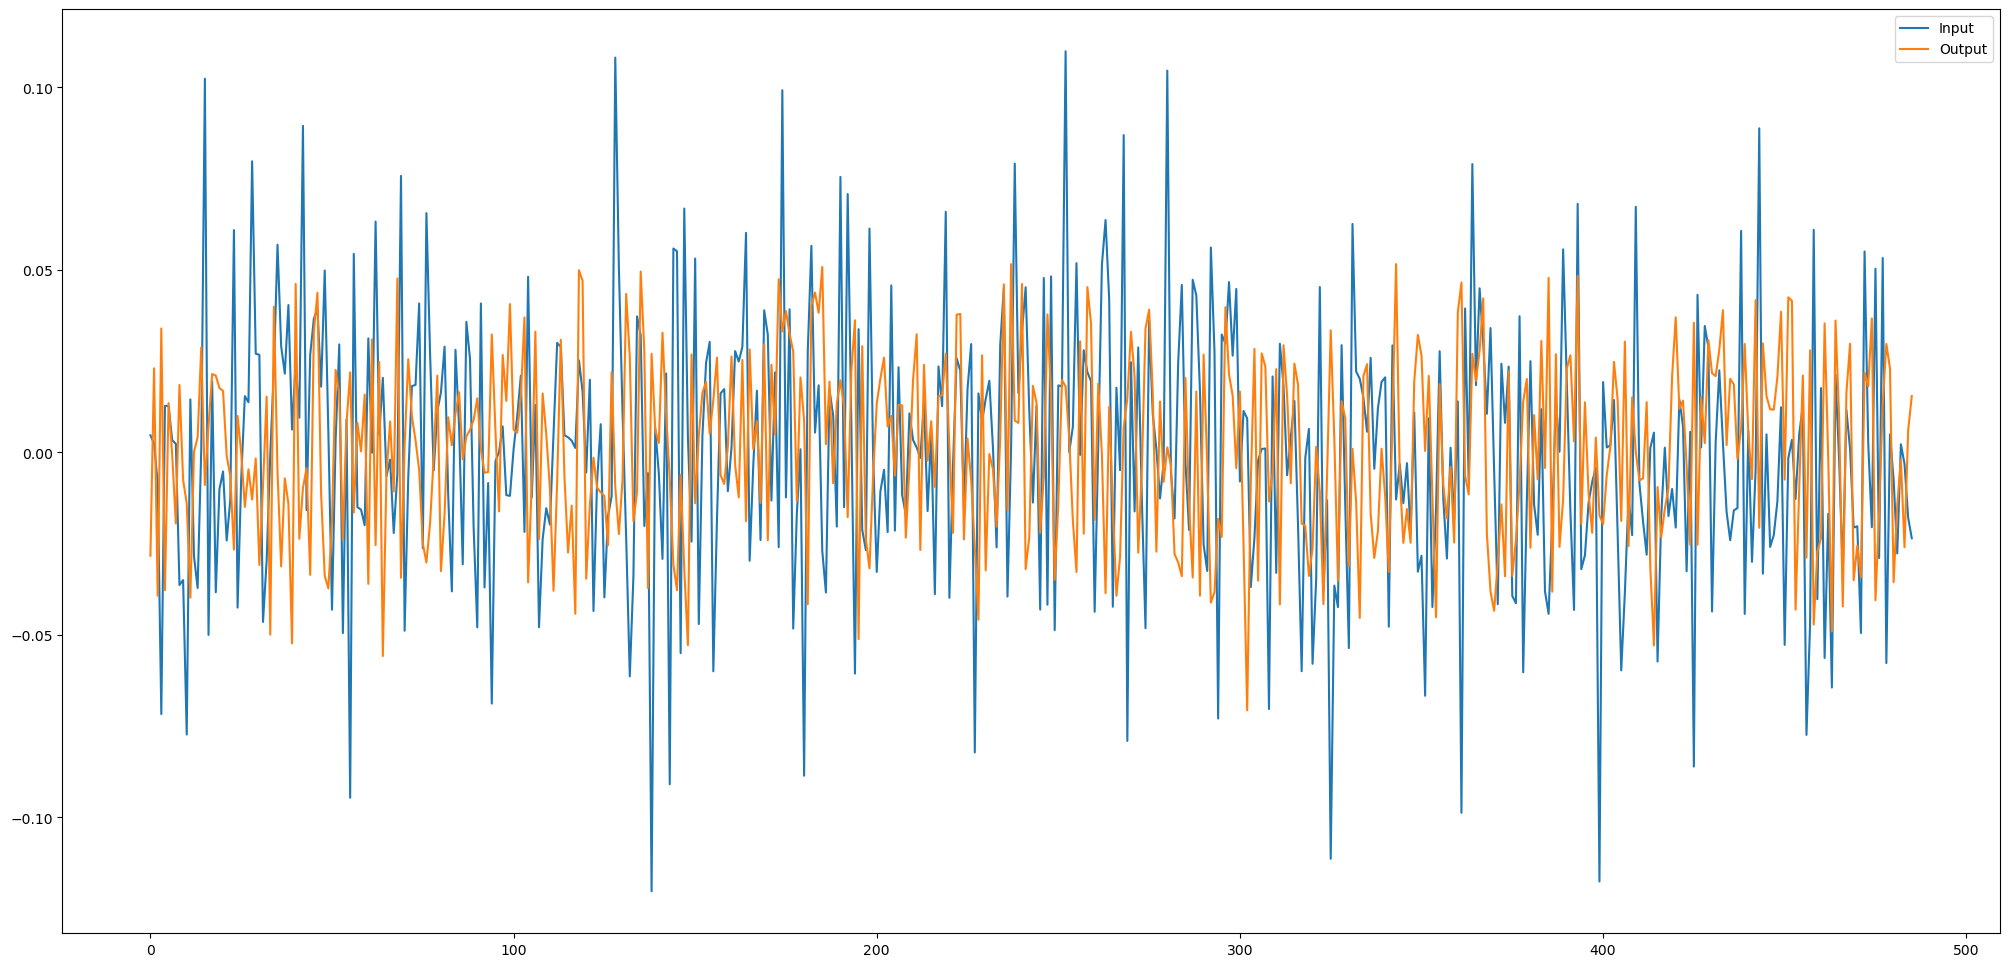

In [112]:
import matplotlib.pyplot as plt
band = 'alpha'
channel = 15

plt.figure(figsize=(25, 12))
plt.plot(inputs[band][0, channel, :].cpu().detach().numpy(), label="Input")
plt.plot(decodings[band][0, channel, :].cpu().detach().numpy(), label="Output")
plt.legend()
plt.show()